# <span style="color:#2F749F;"><strong> Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="right">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

## <span style="color:black;"><strong>Datos del estudiante</strong></span>


*   Jose Camilo Loaiza Hoyos

*   Sarai Restrepo Rodríguez







## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real sobre **vinos**, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.

1. Carga el conjunto de datos **wine** desde la librería `sklearn.datasets` usando `load_wine()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `alcohol`
   - `malic_acid`
   - `color_intensity`

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.datasets import load_diabetes
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import zscore

In [ ]:
wine = load_wine()

df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
print("Las variables disponibles en el dataset son:")
print(df_wine.columns.tolist())

Las variables disponibles en el dataset son:
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [24]:
columnas_seleccionadas_vino = ['alcohol', 'malic_acid', 'magnesium']
df_seleccion = df_wine[columnas_seleccionadas_vino].copy()

print("Datos originales seleccionados (primeras 3 filas):")
print(df_seleccion.head(3))

Datos originales seleccionados (primeras 3 filas):
   alcohol  malic_acid  magnesium
0    14.23        1.71      127.0
1    13.20        1.78      100.0
2    13.16        2.36      101.0


In [42]:
# Inicializar los escaladores de scikit-learn
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Aplicar StandardScaler
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas_vino
)
print("Datos escalados (primeras 3 filas):")
print(df_standard.head(3))

# Aplicar MinMaxScaler
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas_vino
)
print("")
print("Datos escalados con MinMaxScaler (primeras 3 filas):")
print(df_minmax.head(3))

# Aplicar RobustScaler
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_seleccion),
    columns=columnas_seleccionadas_vino
)
print("")
print("Datos escalados con RobustScaler (primeras 3 filas):")
print(df_robust.head(3))

# Aplicar Z-Score
df_zscore = df_seleccion.apply(zscore)
print("")
print("Datos escalados con Z-Score (primeras 3 filas):")
print(df_zscore.head(3))

Datos escalados (primeras 3 filas):
    alcohol  malic_acid  magnesium
0  1.518613   -0.562250   1.913905
1  0.246290   -0.499413   0.018145
2  0.196879    0.021231   0.088358

Datos escalados con MinMaxScaler (primeras 3 filas):
    alcohol  malic_acid  magnesium
0  0.842105    0.191700   0.619565
1  0.571053    0.205534   0.326087
2  0.560526    0.320158   0.336957

Datos escalados con RobustScaler (primeras 3 filas):
    alcohol  malic_acid  magnesium
0  0.897338   -0.104730   1.526316
1  0.114068   -0.057432   0.105263
2  0.083650    0.334459   0.157895

Datos escalados con Z-Score (primeras 3 filas):
    alcohol  malic_acid  magnesium
0  1.518613   -0.562250   1.913905
1  0.246290   -0.499413   0.018145
2  0.196879    0.021231   0.088358


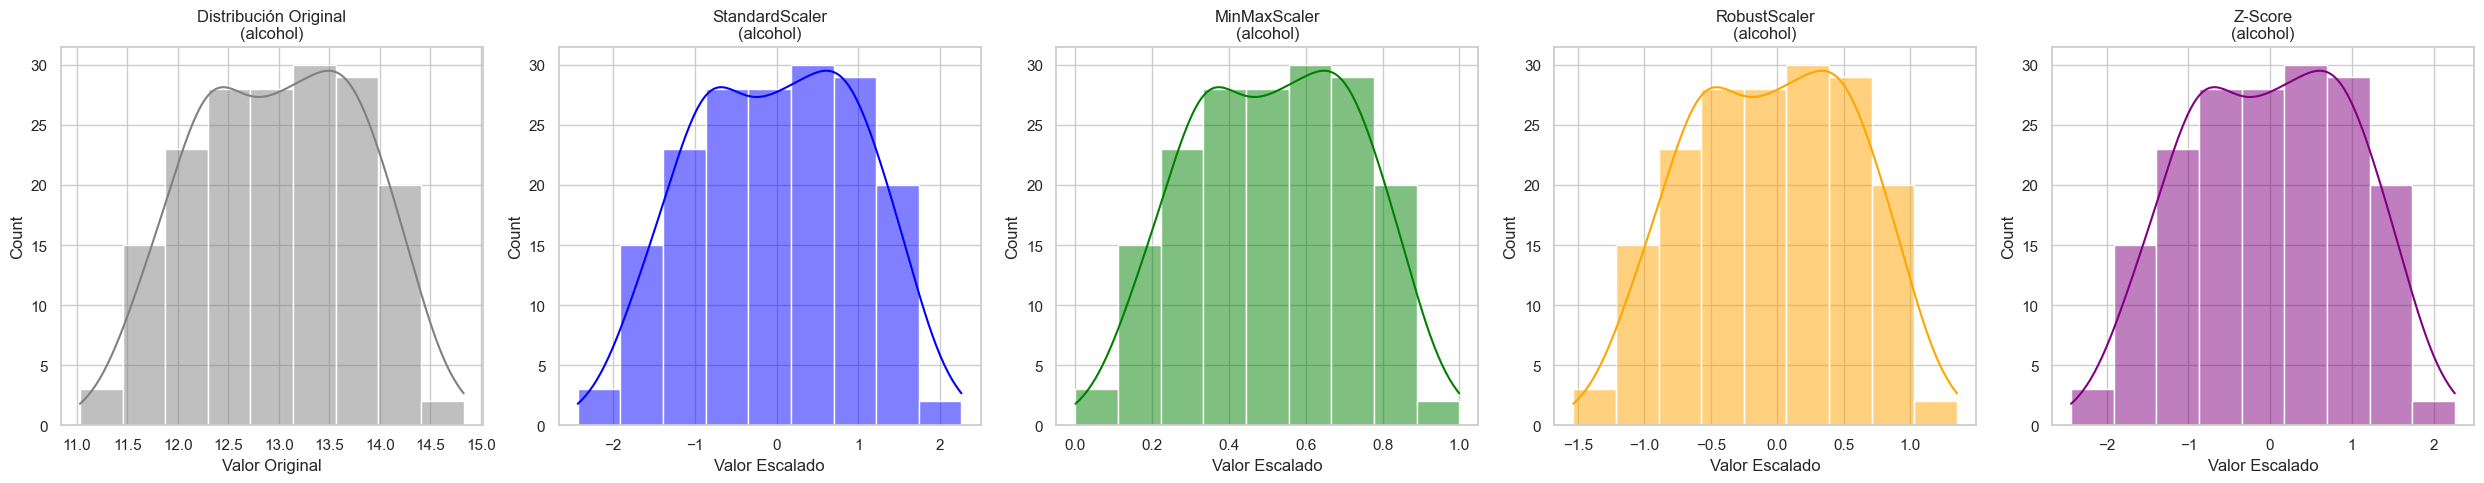

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# variable para comparar
variable = 'alcohol'

# Crear 5 subgráficos
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
sns.set_theme(style="whitegrid")

# 1. Distribución Original
sns.histplot(df_seleccion[variable], kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Distribución Original\n({variable})')
axes[0].set_xlabel('Valor Original')

# 2. Distribución con StandardScaler
sns.histplot(df_standard[variable], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'StandardScaler\n({variable})')
axes[1].set_xlabel('Valor Escalado')

# 3. Distribución con MinMaxScaler
sns.histplot(df_minmax[variable], kde=True, ax=axes[2], color='green')
axes[2].set_title(f'MinMaxScaler\n({variable})')
axes[2].set_xlabel('Valor Escalado')

# 4. Distribución con RobustScaler
sns.histplot(df_robust[variable], kde=True, ax=axes[3], color='orange')
axes[3].set_title(f'RobustScaler\n({variable})')
axes[3].set_xlabel('Valor Escalado')

# 5. Distribución con Z-Score
sns.histplot(df_zscore[variable], kde=True, ax=axes[4], color='purple')
axes[4].set_title(f'Z-Score\n({variable})')
axes[4].set_xlabel('Valor Escalado')

# Ajustar el espaciado para que no se superpongan los textos
plt.tight_layout()

plt.show()

## Análisis de las técnicas de escalamiento

Las técnicas de escalamiento como StandardScaler (Z-Score), MinMaxScaler, RobustScaler y Z-Score transforman las variables para mejorar el rendimiento de modelos sensibles a escalas. 

- StandardScaler y Z-Score centran los datos en media 0 y desviación 1, afectando outliers al mantener su influencia.
- MinMaxScaler escala a [0,1], preservando relaciones pero siendo sensible a outliers extremos.
- RobustScaler usa mediana e IQR, reduciendo el impacto de outliers. 

En términos de impacto, RobustScaler es más robusto en presencia de valores atípicos, mientras que StandardScaler es ideal para distribuciones normales. Se recomienda RobustScaler para datos con outliers, ya que minimiza su efecto sin distorsionar la escala general.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real sobre **diabetes**, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo: `bmi`, `bp`, `s5` u otras disponibles en el dataset).

4. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [ ]:
diabetes = load_diabetes()

df_diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
print("Las variables disponibles en el dataset de diabetes son:")
print(df_diabetes.columns.tolist())

Las variables disponibles en el dataset de diabetes son:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [28]:
columnas_seleccionadas_diab = ['bmi', 'bp', 's5']
df_seleccion_diab = df_diabetes[columnas_seleccionadas_diab].copy()
print(df_seleccion_diab.head(3))

        bmi        bp        s5
0  0.061696  0.021872  0.019907
1 -0.051474 -0.026328 -0.068332
2  0.044451 -0.005670  0.002861


In [29]:
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()


# Aplicar StandardScaler
df_standard_diab = pd.DataFrame(
    standard_scaler.fit_transform(df_seleccion_diab),
    columns=columnas_seleccionadas_diab
)
print("Datos escalados con StandardScaler (primeras 3 filas):")
print(df_standard_diab.head(3))

# Aplicar RobustScaler
df_robust_diab = pd.DataFrame(
    robust_scaler.fit_transform(df_seleccion_diab),
    columns=columnas_seleccionadas_diab
)

print("")
print("Datos escalados con RobustScaler (primeras 3 filas):")
print(df_robust_diab.head(3))

Datos escalados con StandardScaler (primeras 3 filas):
        bmi        bp        s5
0  1.297088  0.459841  0.418531
1 -1.082180 -0.553505 -1.436589
2  0.934533 -0.119214  0.060156

Datos escalados con RobustScaler (primeras 3 filas):
        bmi        bp        s5
0  1.053498  0.380952  0.332755
1 -0.674897 -0.285714 -1.010756
2  0.790123  0.000000  0.073213


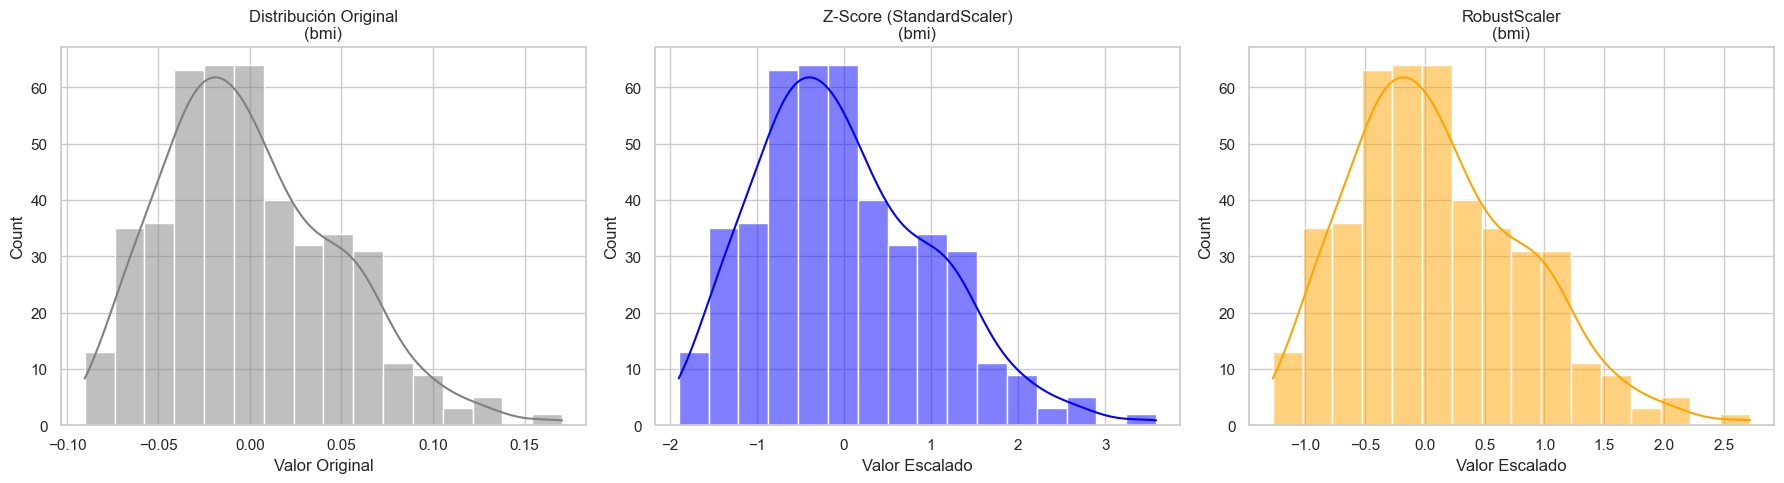

In [ ]:
# variable elegida
variable_diab = 'bmi'

# figura con 3 subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.set_theme(style="whitegrid")

# 1. Distribución Original
sns.histplot(df_seleccion_diab[variable_diab], kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Distribución Original\n({variable_diab})')
axes[0].set_xlabel('Valor Original')

# 2. Distribución con Z-Score (StandardScaler)
sns.histplot(df_standard_diab[variable_diab], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Z-Score (StandardScaler)\n({variable_diab})')
axes[1].set_xlabel('Valor Escalado')

# 3. Distribución con RobustScaler
sns.histplot(df_robust_diab[variable_diab], kde=True, ax=axes[2], color='orange')
axes[2].set_title(f'RobustScaler\n({variable_diab})')
axes[2].set_xlabel('Valor Escalado')

plt.tight_layout()

plt.show()

## Análisis de las técnicas de escalamiento

StandardScaler (Z-Score) centra los datos en media 0 y desviación estándar 1, pero es sensible a valores atípicos que pueden distorsionar significativamente el escalamiento. RobustScaler, en cambio, utiliza la mediana e IQR, lo que los hace mucho más resistentes a outliers y valores extremos. 

Visualmente, en presencia de anomalías, RobustScaler mantiene una escala más uniforme, mientras que StandardScaler amplifica los efectos de los outliers. RobustScaler es preferible para datasets con posibles valores atípicos permitiendo una normalización más robusta y fiable para modelos de machine learning.


## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real sobre **precios de viviendas**, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Carga el conjunto de datos **California Housing** desde la librería `sklearn.datasets` usando `fetch_california_housing()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **tres variables numéricas** para el análisis (por ejemplo):
   - `MedInc`
   - `AveRooms`
   - `HouseAge`

4. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

5. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [31]:
california = fetch_california_housing()

df_california = pd.DataFrame(california.data, columns=california.feature_names)
print("Las variables disponibles en el dataset de California Housing son:")
print(df_california.columns.tolist())

Las variables disponibles en el dataset de California Housing son:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [32]:
from sklearn.preprocessing import Normalizer

# Seleccionar 3 columnas
columnas_california = ['MedInc', 'AveRooms', 'HouseAge']
df_seleccion_california = df_california[columnas_california].copy()

print("Datos originales seleccionados (primeras 3 filas):")
print(df_seleccion_california.head(3))

# Aplicar Normalización L1
normalizer_l1 = Normalizer(norm='l1')
df_l1 = pd.DataFrame(
    normalizer_l1.fit_transform(df_seleccion_california),
    columns=columnas_california
)

# Aplicar Normalización L2
normalizer_l2 = Normalizer(norm='l2')
df_l2 = pd.DataFrame(
    normalizer_l2.fit_transform(df_seleccion_california),
    columns=columnas_california
)

print("\nDatos con normalización L1 (primeras 3 filas):")
print(df_l1.head(3))

print("\nDatos con normalización L2 (primeras 3 filas):")
print(df_l2.head(3))

Datos originales seleccionados (primeras 3 filas):
   MedInc  AveRooms  HouseAge
0  8.3252  6.984127      41.0
1  8.3014  6.238137      21.0
2  7.2574  8.288136      52.0

Datos con normalización L1 (primeras 3 filas):
     MedInc  AveRooms  HouseAge
0  0.147848  0.124031  0.728121
1  0.233582  0.175527  0.590891
2  0.107445  0.122704  0.769851

Datos con normalización L2 (primeras 3 filas):
     MedInc  AveRooms  HouseAge
0  0.196277  0.164659  0.966624
1  0.354351  0.266279  0.896399
2  0.136535  0.155926  0.978287


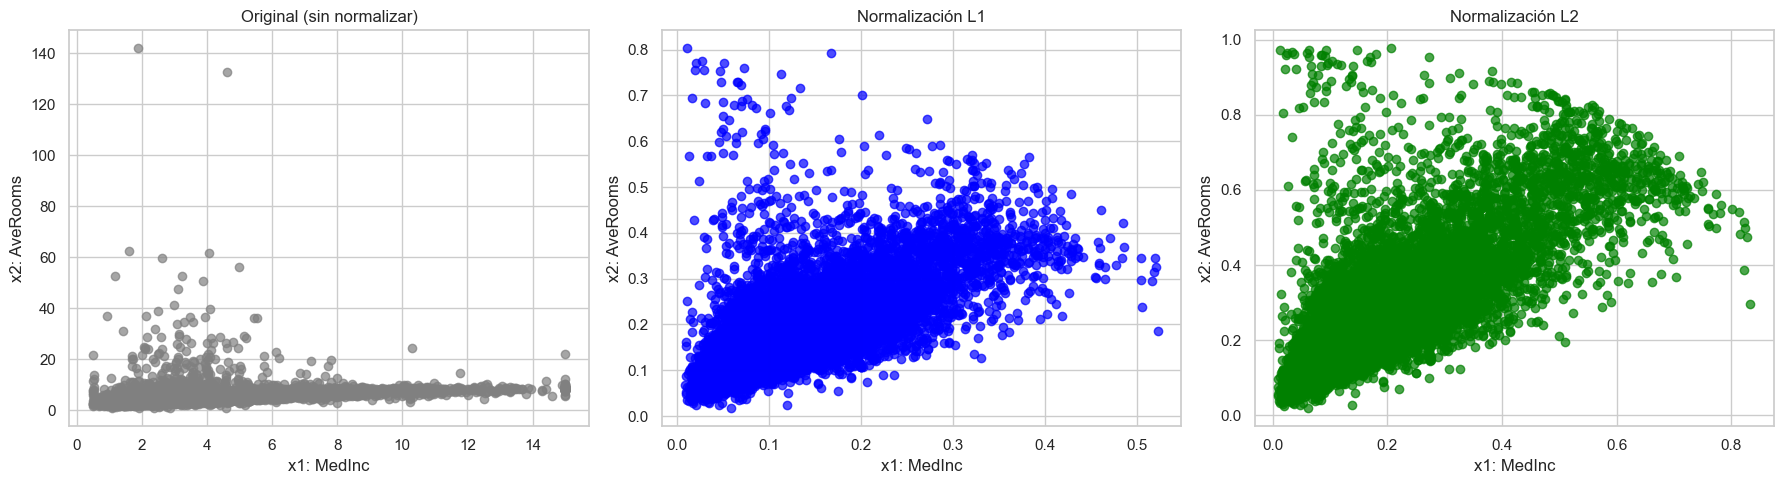

In [33]:
# Gráfica tipo scatter 2D basada en x1 vs x2
# Usamos dos variables para visualizar el efecto de la normalización
vars_scatter = ['MedInc', 'AveRooms']

X_original = df_seleccion_california[vars_scatter].values
X_l1 = df_l1[vars_scatter].values
X_l2 = df_l2[vars_scatter].values

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Original
axs[0].scatter(X_original[:, 0], X_original[:, 1], color='gray', alpha=0.7)
axs[0].set_title('Original (sin normalizar)')
axs[0].set_xlabel('x1: MedInc')
axs[0].set_ylabel('x2: AveRooms')
axs[0].grid(True)

# L1
axs[1].scatter(X_l1[:, 0], X_l1[:, 1], color='blue', alpha=0.7)
axs[1].set_title('Normalización L1')
axs[1].set_xlabel('x1: MedInc')
axs[1].set_ylabel('x2: AveRooms')
axs[1].grid(True)

# L2
axs[2].scatter(X_l2[:, 0], X_l2[:, 1], color='green', alpha=0.7)
axs[2].set_title('Normalización L2')
axs[2].set_xlabel('x1: MedInc')
axs[2].set_ylabel('x2: AveRooms')
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Análisis de las técnicas de escalamiento

- La normalización L1 (Manhattan) escala los datos de forma que la suma de sus valores absolutos = 1, 
produciendo distribuciones más dispersas y esparse. 
- La normalización L2 (Euclidean) escala de modo que la suma de cuadrados = 1, 
preservando mejor las relaciones de magnitud entre variables. Visualmente, L1 distribuye los datos de forma más dispersa, mientras que L2 mantiene clusters más compactos. 

L2 es preferible ya que preserva mejor las relaciones geométricas entre datos y es menos sensible a valores atípicos que L1.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con diabetes**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos **diabetes** desde la librería `sklearn.datasets` usando `load_diabetes()`.

2. Convierte el conjunto de datos en un **DataFrame de pandas** e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo: `bmi`, `bp` o `s5`).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [34]:
import numpy as np
from scipy.stats import boxcox

# Variable elegida para el análisis
variable_transform = 'bmi'

# Obtener la variable original
X_original = df_seleccion_diab[variable_transform].values

X_log = np.log1p(X_original)


X_reflected = np.max(X_original) - X_original
X_log_reflected = np.log1p(X_reflected)

X_quadratic = X_original ** 2

X_positive = X_original + abs(X_original.min()) + 1
X_boxcox, lambda_param = boxcox(X_positive)

print(f"Variable transformada: {variable_transform}")
print(f"Valores originales - Min: {X_original.min():.2f}, Max: {X_original.max():.2f}, Mean: {X_original.mean():.2f}")
print(f"Parámetro lambda de Box-Cox: {lambda_param:.4f}")

transformations_df = pd.DataFrame({
    'Original': X_original,
    'Log': X_log,
    'Log Reflejado': X_log_reflected,
    'Cuadrática': X_quadratic,
    'Box-Cox': X_boxcox
})

print("\nPrimeras 3 filas de las transformaciones:")
print(transformations_df.head(3))

Variable transformada: bmi
Valores originales - Min: -0.09, Max: 0.17, Mean: -0.00
Parámetro lambda de Box-Cox: -4.5600

Primeras 3 filas de las transformaciones:
   Original       Log  Log Reflejado  Cuadrática   Box-Cox
0  0.061696  0.059868       0.103332    0.003806  0.104255
1 -0.051474 -0.052846       0.200513    0.002650  0.034947
2  0.044451  0.043492       0.118764    0.001976  0.096064


In [35]:
# Seleccionar al menos dos variables numéricas para el análisis
columnas_seleccionadas_diab = ['bmi', 'bp', 's5']
df_seleccion_diab = df_diabetes[columnas_seleccionadas_diab].copy()
print("Variables seleccionadas para el análisis:")
print(columnas_seleccionadas_diab)

# Aplicar transformaciones sobre una de las variables seleccionadas (bp)
import numpy as np
from scipy.stats import boxcox

variable_transform = 'bp'

X_original = df_seleccion_diab[variable_transform].values

# Transformación logarítmica
X_log = np.log1p(X_original)

# Transformación logarítmica reflejada
X_reflected = np.max(X_original) - X_original
X_log_reflected = np.log1p(X_reflected)

# Transformación cuadrática
X_quadratic = X_original ** 2

# Transformación Box-Cox
X_positive = X_original + abs(X_original.min()) + 1
X_boxcox, lambda_param = boxcox(X_positive)

print(f"\nVariable transformada: {variable_transform}")
print(f"Valores originales - Min: {X_original.min():.2f}, Max: {X_original.max():.2f}, Mean: {X_original.mean():.2f}")
print(f"Parámetro lambda de Box-Cox: {lambda_param:.4f}")

transformations_df = pd.DataFrame({
    'Original': X_original,
    'Log': X_log,
    'Log Reflejado': X_log_reflected,
    'Cuadrática': X_quadratic,
    'Box-Cox': X_boxcox
})

print("\nPrimeras 3 filas de las transformaciones:")
print(transformations_df.head(3))

Variables seleccionadas para el análisis:
['bmi', 'bp', 's5']

Variable transformada: bp
Valores originales - Min: -0.11, Max: 0.13, Mean: -0.00
Parámetro lambda de Box-Cox: -2.0582

Primeras 3 filas de las transformaciones:
   Original       Log  Log Reflejado  Cuadrática   Box-Cox
0  0.021872  0.021637       0.104514    0.000478  0.110980
1 -0.026328 -0.026680       0.147015    0.000693  0.075932
2 -0.005670 -0.005687       0.129021    0.000032  0.091525


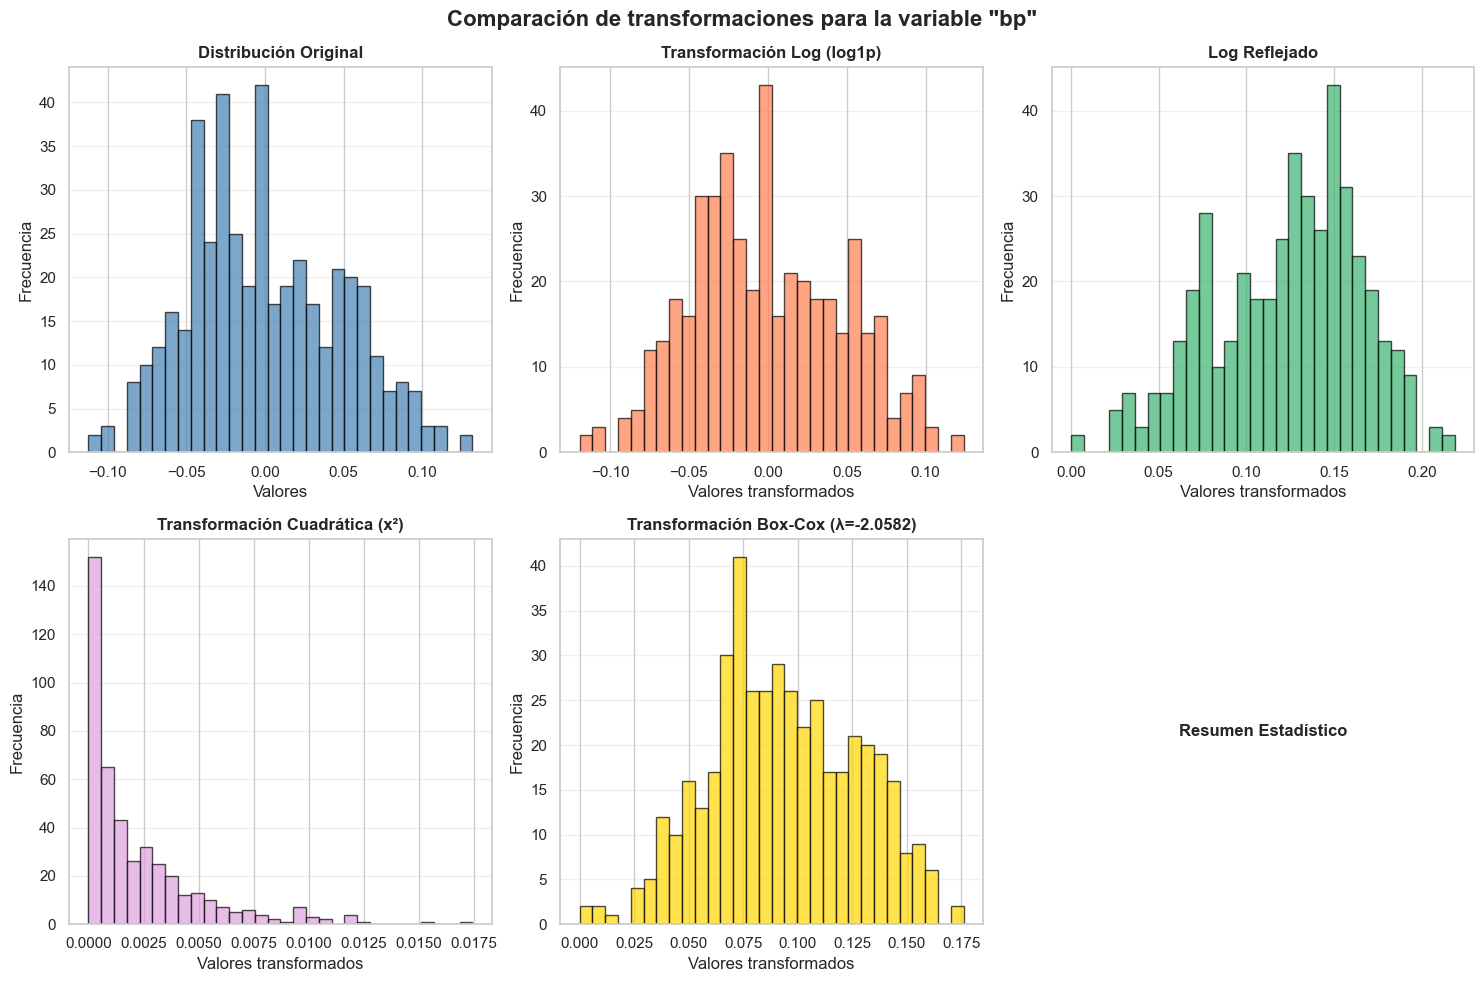


ESTADÍSTICAS DESCRIPTIVAS DE LAS TRANSFORMACIONES
            Original     Log  Log Reflejado  Cuadrática  Box-Cox
Media        -0.0000 -0.0011         0.1231      0.0023   0.0934
Desv. Est.    0.0476  0.0473         0.0423      0.0027   0.0341
Mínimo       -0.1124 -0.1192         0.0000      0.0000   0.0000
Máximo        0.1320  0.1240         0.2187      0.0174   0.1761

MEDIDAS DE SIMETRÍA Y CURTOSIS
               Simetría (Skewness)  Curtosis (Kurtosis)
Original                    0.2897              -0.5403
Log                         0.1915              -0.5740
Log Reflejado              -0.3771              -0.4783
Cuadrática                  1.9953               4.7871
Box-Cox                     0.0171              -0.5611

Nota: Un valor de simetría cercano a 0 indica una distribución más simétrica.


In [46]:
# Crear gráficas comparativas de las distribuciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'Comparación de transformaciones para la variable "{variable_transform}"', fontsize=16, fontweight='bold')

# Distribución original
axes[0, 0].hist(X_original, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución Original', fontweight='bold')
axes[0, 0].set_xlabel('Valores')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

# Transformación logarítmica
axes[0, 1].hist(X_log, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Transformación Log (log1p)', fontweight='bold')
axes[0, 1].set_xlabel('Valores transformados')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(axis='y', alpha=0.3)

# Transformación logarítmica reflejada
axes[0, 2].hist(X_log_reflected, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Log Reflejado', fontweight='bold')
axes[0, 2].set_xlabel('Valores transformados')
axes[0, 2].set_ylabel('Frecuencia')
axes[0, 2].grid(axis='y', alpha=0.3)

# Transformación cuadrática
axes[1, 0].hist(X_quadratic, bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Transformación Cuadrática (x²)', fontweight='bold')
axes[1, 0].set_xlabel('Valores transformados')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(axis='y', alpha=0.3)

# Transformación Box-Cox
axes[1, 1].hist(X_boxcox, bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title(f'Transformación Box-Cox (λ={lambda_param:.4f})', fontweight='bold')
axes[1, 1].set_xlabel('Valores transformados')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(axis='y', alpha=0.3)

# Comparación mediante KDE (densidad)
axes[1, 2].axis('off')
axes[1, 2].text(0.5, 0.5, 'Resumen Estadístico', ha='center', va='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de cada transformación
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE LAS TRANSFORMACIONES")
print("="*80)

stats_df = pd.DataFrame({
    'Original': [X_original.mean(), X_original.std(), X_original.min(), X_original.max()],
    'Log': [X_log.mean(), X_log.std(), X_log.min(), X_log.max()],
    'Log Reflejado': [X_log_reflected.mean(), X_log_reflected.std(), X_log_reflected.min(), X_log_reflected.max()],
    'Cuadrática': [X_quadratic.mean(), X_quadratic.std(), X_quadratic.min(), X_quadratic.max()],
    'Box-Cox': [X_boxcox.mean(), X_boxcox.std(), X_boxcox.min(), X_boxcox.max()]
}, index=['Media', 'Desv. Est.', 'Mínimo', 'Máximo'])

print(stats_df.round(4))

# Calcular simetría (skewness) de cada transformación
from scipy.stats import skew, kurtosis

print("\n" + "="*80)
print("MEDIDAS DE SIMETRÍA Y CURTOSIS")
print("="*80)

skewness_df = pd.DataFrame({
    'Simetría (Skewness)': [skew(X_original), skew(X_log), skew(X_log_reflected), skew(X_quadratic), skew(X_boxcox)],
    'Curtosis (Kurtosis)': [kurtosis(X_original), kurtosis(X_log), kurtosis(X_log_reflected), kurtosis(X_quadratic), kurtosis(X_boxcox)]
}, index=['Original', 'Log', 'Log Reflejado', 'Cuadrática', 'Box-Cox'])

print(skewness_df.round(4))
print("\nNota: Un valor de simetría cercano a 0 indica una distribución más simétrica.")

## Análisis de las técnicas de escalamiento

La transformación logarítmica reduce la asimetría (0.29 → 0.19) mediante compresión suave de 
valores altos. El log reflejado invierte la asimetría (-0.38) pero la aumenta. La transformación 
cuadrática empeora drásticamente la simetría (1.99), amplificando valores altos. Box-Cox es superior 
al alcanzar casi perfecta simetría (0.017) mediante optimización automática del parámetro λ, 
adaptándose específicamente a los datos.

Box-Cox es preferible para reducir asimetría porque encuentra automáticamente la transformación óptima sin ajuste manual, garantizando máxima normalidad en los datos transformados.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

A partir de un conjunto de datos real sobre **pacientes con enfermedades cardíacas**, analiza cómo cambian las distribuciones de algunas variables clínicas al aplicar diferentes **transformaciones matemáticas utilizadas para reducir la asimetría (skewness) o estabilizar la varianza**.

1. Carga el conjunto de datos Heart Disease desde la librería `ucimlrepo` usando `load_dataset("heart_disease = fetch_ucirepo(id=45)")`.

2. Convierte el conjunto de datos en un DataFrame de pandas e identifica las variables disponibles.

3. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  
   - `chol` (colesterol)  
   - `trestbps` (presión arterial en reposo)  
   - `thalach` (frecuencia cardíaca máxima)).

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

In [37]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

df_heart = pd.DataFrame(heart_disease.data.features)
print("Las variables disponibles en el dataset de Heart Disease son:")
print(df_heart.columns.tolist())

Las variables disponibles en el dataset de Heart Disease son:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [38]:
#Paso 3
columnas_seleccionadas_heart = ['chol', 'trestbps', 'thalach']
df_seleccion_heart = df_heart[columnas_seleccionadas_heart].copy()

print("Variables seleccionadas para el análisis:")
print(columnas_seleccionadas_heart)
print("\nPrimeras 3 filas:")
print(df_seleccion_heart.head(3))

Variables seleccionadas para el análisis:
['chol', 'trestbps', 'thalach']

Primeras 3 filas:
   chol  trestbps  thalach
0   233       145      150
1   286       160      108
2   229       120      129


In [39]:
import numpy as np
from sklearn.preprocessing import PowerTransformer

variable_heart = 'chol'

X_original_heart = df_seleccion_heart[variable_heart].values

# Transformación raíz cuadrada
X_sqrt = np.sqrt(X_original_heart)

# Transformación recíproca (1/x)
X_reciprocal = 1 / X_original_heart

# Transformación Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
X_yeojohnson = pt.fit_transform(X_original_heart.reshape(-1, 1)).flatten()

print(f"Variable transformada: {variable_heart}")
print(f"Valores originales - Min: {X_original_heart.min():.2f}, Max: {X_original_heart.max():.2f}, Mean: {X_original_heart.mean():.2f}")

transformations_heart_df = pd.DataFrame({
    'Original': X_original_heart,
    'Raíz Cuadrada': X_sqrt,
    'Recíproca': X_reciprocal,
    'Yeo-Johnson': X_yeojohnson
})

print("\nPrimeras 3 filas de las transformaciones:")
print(transformations_heart_df.head(3))

Variable transformada: chol
Valores originales - Min: 126.00, Max: 564.00, Mean: 246.69

Primeras 3 filas de las transformaciones:
   Original  Raíz Cuadrada  Recíproca  Yeo-Johnson
0       233      15.264338   0.004292    -0.169500
1       286      16.911535   0.003497     0.833883
2       229      15.132746   0.004367    -0.255179


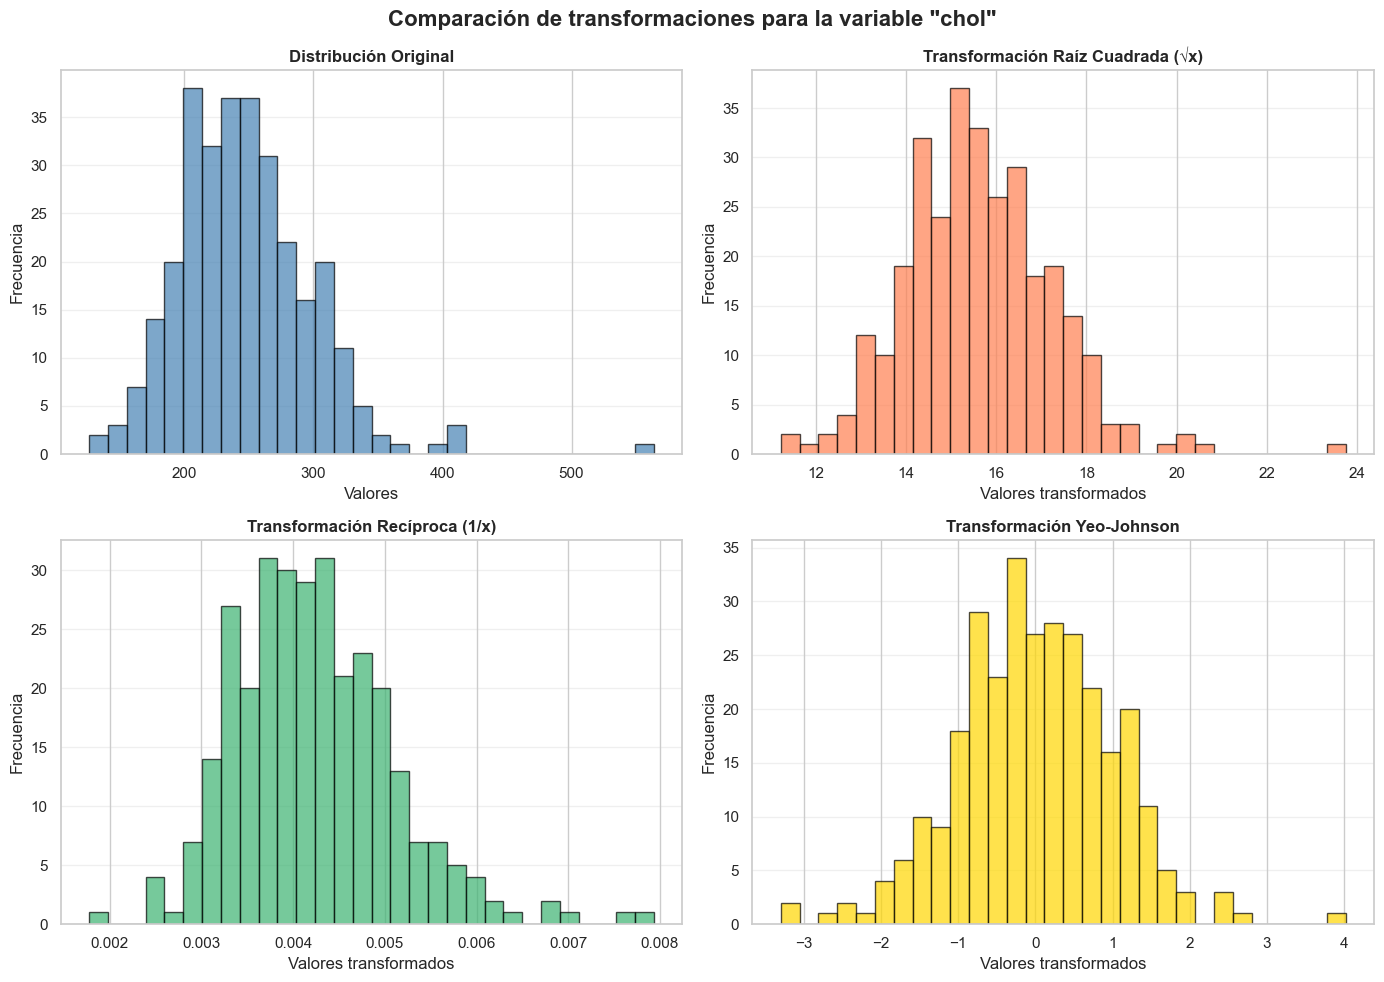


ESTADÍSTICAS DESCRIPTIVAS DE LAS TRANSFORMACIONES
            Original  Raíz Cuadrada  Recíproca  Yeo-Johnson
Media       246.6931        15.6246     0.0042      -0.0000
Desv. Est.   51.6914         1.6016     0.0009       1.0000
Mínimo      126.0000        11.2250     0.0018      -3.2984
Máximo      564.0000        23.7487     0.0079       4.0198

MEDIDAS DE SIMETRÍA Y CURTOSIS
               Simetría (Skewness)  Curtosis (Kurtosis)
Original                    1.1299               4.3982
Raíz Cuadrada               0.5513               1.8834
Recíproca                   0.7633               1.5720
Yeo-Johnson                -0.0057               0.8327

Nota: Un valor de simetría cercano a 0 indica una distribución más simétrica.


In [48]:
# Crear gráficas comparativas de las distribuciones
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Comparación de transformaciones para la variable "{variable_heart}"', fontsize=16, fontweight='bold')

# Distribución original
axes[0, 0].hist(X_original_heart, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución Original', fontweight='bold')
axes[0, 0].set_xlabel('Valores')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

# Transformación raíz cuadrada
axes[0, 1].hist(X_sqrt, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Transformación Raíz Cuadrada (√x)', fontweight='bold')
axes[0, 1].set_xlabel('Valores transformados')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(axis='y', alpha=0.3)

# Transformación recíproca
axes[1, 0].hist(X_reciprocal, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Transformación Recíproca (1/x)', fontweight='bold')
axes[1, 0].set_xlabel('Valores transformados')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(axis='y', alpha=0.3)

# Transformación Yeo-Johnson
axes[1, 1].hist(X_yeojohnson, bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Transformación Yeo-Johnson', fontweight='bold')
axes[1, 1].set_xlabel('Valores transformados')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de cada transformación
print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE LAS TRANSFORMACIONES")
print("="*80)

stats_heart_df = pd.DataFrame({
    'Original': [X_original_heart.mean(), X_original_heart.std(), X_original_heart.min(), X_original_heart.max()],
    'Raíz Cuadrada': [X_sqrt.mean(), X_sqrt.std(), X_sqrt.min(), X_sqrt.max()],
    'Recíproca': [X_reciprocal.mean(), X_reciprocal.std(), X_reciprocal.min(), X_reciprocal.max()],
    'Yeo-Johnson': [X_yeojohnson.mean(), X_yeojohnson.std(), X_yeojohnson.min(), X_yeojohnson.max()]
}, index=['Media', 'Desv. Est.', 'Mínimo', 'Máximo'])

print(stats_heart_df.round(4))

# Calcular simetría (skewness) de cada transformación
from scipy.stats import skew, kurtosis

print("\n" + "="*80)
print("MEDIDAS DE SIMETRÍA Y CURTOSIS")
print("="*80)

skewness_heart_df = pd.DataFrame({
    'Simetría (Skewness)': [skew(X_original_heart), skew(X_sqrt), skew(X_reciprocal), skew(X_yeojohnson)],
    'Curtosis (Kurtosis)': [kurtosis(X_original_heart), kurtosis(X_sqrt), kurtosis(X_reciprocal), kurtosis(X_yeojohnson)]
}, index=['Original', 'Raíz Cuadrada', 'Recíproca', 'Yeo-Johnson'])

print(skewness_heart_df.round(4))
print("\nNota: Un valor de simetría cercano a 0 indica una distribución más simétrica.")

## Análisis de las técnicas de escalamiento

- La raíz cuadrada comprime valores moderadamente, reduciendo asimetría de 1.13 a 0.55 
sin perder interpretabilidad de la escala original. 
- La transformación recíproca es menos efectiva (0.76) e introduce inversión de relaciones entre magnitudes. 
- Yeo-Johnson destaca por lograr perfecta simetría (-0.006) mediante optimización automática sin requiero ajuste manual del parámetro. 

Yeo-Johnson es superior para normalizar distribuciones asimétricas porque adapta automáticamente su transformación a los datos, garantizando máxima reducción de asimetría y curtosis sin sesgo interpretativo.